In [15]:

import os
#os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.98"

import numpy as np
import matplotlib.pyplot as plt

from dmri.simulators import AllGaussianModels
from model_segmentation_plot import _shorthand

plt.style.use("../../dmri/utils/pyloric.mplstyle")

from ksd_eval_all import (
    plot_violin,
    group_by_mask_list,
    trim_values,
    normalize_by_prior,
    mask_to_label,
    mask_parameter_count,
)


In [16]:
data_syn = np.load("synthetic_short_ksd_per_mask.npz", allow_pickle=True)
data_real = np.load("real_random_short_ksd_per_mask.npz", allow_pickle=True)
data_real_sel = np.load("real_selected_short_ksd_per_mask.npz", allow_pickle=True)


In [17]:
data_syn_long = np.load("synthetic_long_ksd_per_mask.npz", allow_pickle=True)
data_real_long = np.load("real_random_long_ksd_per_mask.npz", allow_pickle=True)
data_real_sel_long = np.load("real_selected_long_ksd_per_mask.npz", allow_pickle=True)


In [33]:
np.nanmedian(data_syn["ksd"])

np.float32(0.6530683)

In [34]:
np.nanmedian(data_real["ksd"])

np.float32(4.738676)

In [32]:
np.nanmedian(data_real_sel["ksd"])

np.float32(4.2198987)

In [ ]:
np.nansum(data_real_sel["ksd"] > -1.)

np.int64(49999)

: 

In [18]:
def preprocess(data, mask_list):
    ksds_short = data["ksd"]
    ksds_short_prior = data["ksd_prior"]
    masks_short = data["mask_support"]
    ksd_short_model = group_by_mask_list(ksds_short, masks_short, mask_list)
    ksd_short_prior_model = group_by_mask_list(
        ksds_short_prior, masks_short, mask_list
    )
    ksd_short_ratio = normalize_by_prior(ksd_short_model, ksd_short_prior_model)
    ksd_short_ratio = trim_values(ksd_short_ratio, 0.99)
    return ksd_short_ratio


In [19]:
MODEL_TYPES = AllGaussianModels.model_types
NOISE_TYPES = AllGaussianModels.noise_types

from collections import defaultdict

def _counts_or_zeros(data):
    if "ksd_counts" in data.files:
        return np.asarray(data["ksd_counts"])
    return np.zeros(data["mask_support"].shape[0], dtype=int)

def _shorten_noise(noise):
    noise = noise.replace("Bounded", "")
    if noise.startswith("Gaussian"):
        return "G"
    if noise.startswith("Rician"):
        return "R"
    return noise[:1].upper()

def shorten_label(label):
    if label == "None":
        return label
    if "|" in label:
        model, noise = label.split("|", 1)
        return f"{_shorthand(model)}|{_shorten_noise(noise)}"
    return _shorthand(label)

def _accumulate_counts(datasets):
    counts = defaultdict(int)
    for data in datasets:
        masks = np.asarray(data["mask_support"])
        mask_counts = _counts_or_zeros(data)
        for mask, count in zip(masks, mask_counts):
            counts[tuple(mask.tolist())] += int(count)
    return counts

def select_mask_groups(data_syn, data_real, max_groups=30, per_param=3):
    syn_counts = _accumulate_counts(data_syn)
    real_counts = _accumulate_counts(data_real)
    keys = set(syn_counts) | set(real_counts)
    entries = []
    for key in keys:
        mask = np.array(key, dtype=bool)
        syn = syn_counts.get(key, 0)
        real = real_counts.get(key, 0)
        score = min(syn, real)
        label = shorten_label(mask_to_label(mask, MODEL_TYPES, NOISE_TYPES))
        param_count = mask_parameter_count(mask, MODEL_TYPES, NOISE_TYPES)
        entries.append(
            {
                "mask": mask,
                "label": label,
                "param": param_count,
                "syn": syn,
                "real": real,
                "score": score,
            }
        )
    entries.sort(
        key=lambda item: (
            -item["score"],
            -(item["syn"] + item["real"]),
            item["param"],
            item["label"],
        )
    )

    selected = []
    per_param_counts = defaultdict(int)
    for entry in entries:
        if entry["score"] == 0:
            continue
        if max_groups is not None and max_groups > 0 and len(selected) >= max_groups:
            break
        if per_param and per_param_counts[entry["param"]] >= per_param:
            continue
        selected.append(entry)
        per_param_counts[entry["param"]] += 1

    if max_groups is None or max_groups <= 0 or len(selected) < max_groups:
        for entry in entries:
            if max_groups is not None and max_groups > 0 and len(selected) >= max_groups:
                break
            if entry in selected:
                continue
            selected.append(entry)

    if not selected:
        return np.zeros((0, 0), dtype=bool), []
    selected.sort(key=lambda item: (item["param"], item["label"]))
    mask_list = np.stack([item["mask"] for item in selected], axis=0)
    labels = [item["label"] for item in selected]
    return mask_list, labels

mask_list, labels = select_mask_groups(
    [data_syn, data_syn_long],
    [data_real, data_real_long],
    max_groups=30,
    per_param=3,
)


In [20]:
data_syn["mask_support"].sum(axis=-1)

array([ 1,  1,  2, ..., 10, 11, 11], shape=(2048,))

(0.0001, 1.0)

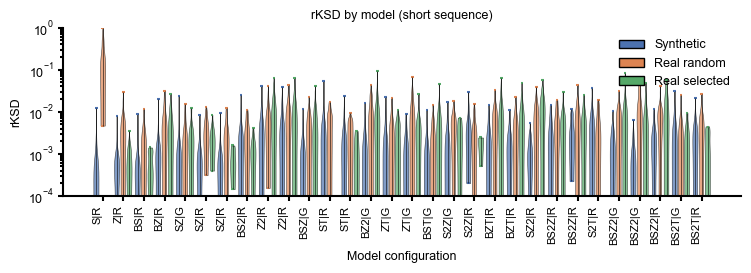

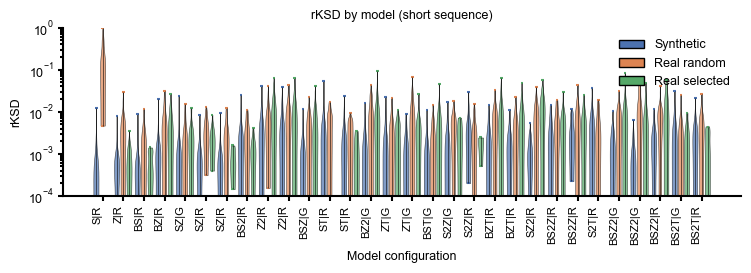

In [21]:
ksds_short_syn = preprocess(data_syn, mask_list)
ksds_short_real = preprocess(data_real, mask_list)
ksds_short_real_sel = preprocess(data_real_sel, mask_list)

group_labels = ["Synthetic", "Real random", "Real selected"]
colors = ["#4C72B0", "#DD8452", "#55A868"]

fig, ax = plot_violin(
    [ksds_short_syn, ksds_short_real, ksds_short_real_sel],
    labels,
    "joint_violin_short.png",
    "rKSD by model (short sequence)",
    "rKSD",
    group_labels=group_labels,
    colors=colors,
    figsize=(7.5, 2.8),
    violin_width=0.25,
    group_span=0.6,
    rotation=90,
)
ax.set_yscale("log")
ax.set_ylim(1e-4, 1.)
fig, ax = plot_violin(
    [ksds_short_syn, ksds_short_real, ksds_short_real_sel],
    labels,
    "joint_violin_short.svg",
    "rKSD by model (short sequence)",
    "rKSD",
    group_labels=group_labels,
    colors=colors,
    figsize=(7.5, 2.8),
    violin_width=0.25,
    group_span=0.6,
    rotation=90,
)
ax.set_yscale("log")
ax.set_ylim(1e-4, 1.)


(0.0001, 1.0)

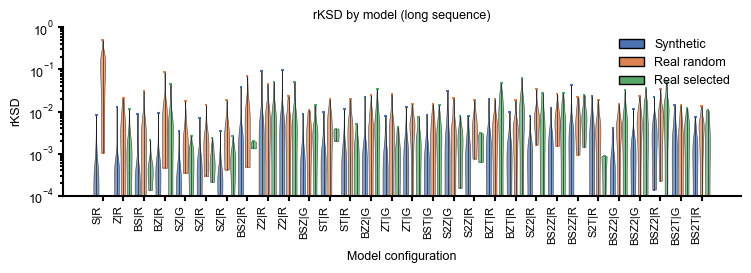

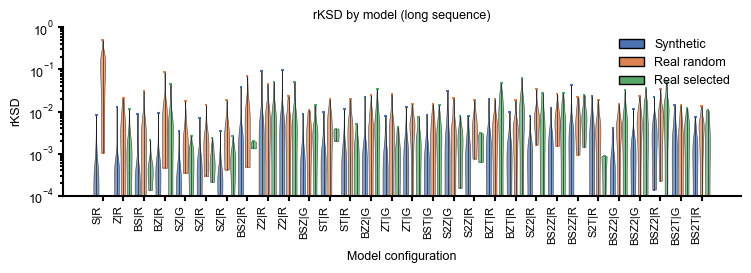

In [22]:
ksds_long_syn = preprocess(data_syn_long, mask_list)
ksds_long_real = preprocess(data_real_long, mask_list)
ksds_long_real_sel = preprocess(data_real_sel_long, mask_list)

fig, ax = plot_violin(
    [ksds_long_syn, ksds_long_real, ksds_long_real_sel],
    labels,
    "joint_violin_long.png",
    "rKSD by model (long sequence)",
    "rKSD",
    group_labels=group_labels,
    colors=colors,
    figsize=(7.5, 2.8),
    violin_width=0.25,
    group_span=0.6,
    rotation=90,
)
ax.set_yscale("log")
ax.set_ylim(1e-4, 1.)
fig, ax = plot_violin(
    [ksds_long_syn, ksds_long_real, ksds_long_real_sel],
    labels,
    "joint_violin_long.svg",
    "rKSD by model (long sequence)",
    "rKSD",
    group_labels=group_labels,
    colors=colors,
    figsize=(7.5, 2.8),
    violin_width=0.25,
    group_span=0.6,
    rotation=90,
)
ax.set_yscale("log")
ax.set_ylim(1e-4, 1.)
